In [1]:
from google.colab import files
uploaded = files.upload()

Saving data_to_be_cleansed.csv to data_to_be_cleansed.csv


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


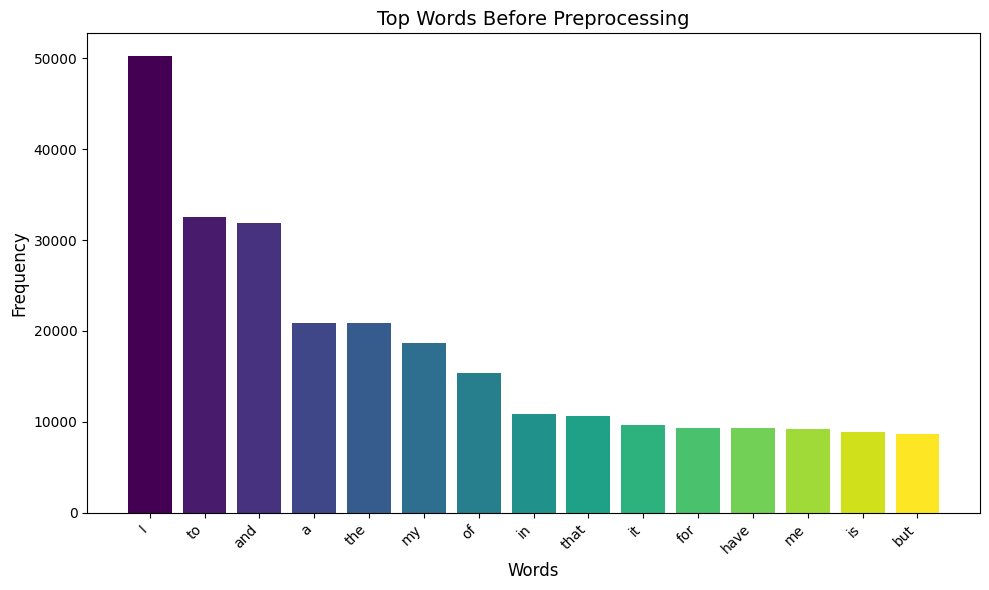

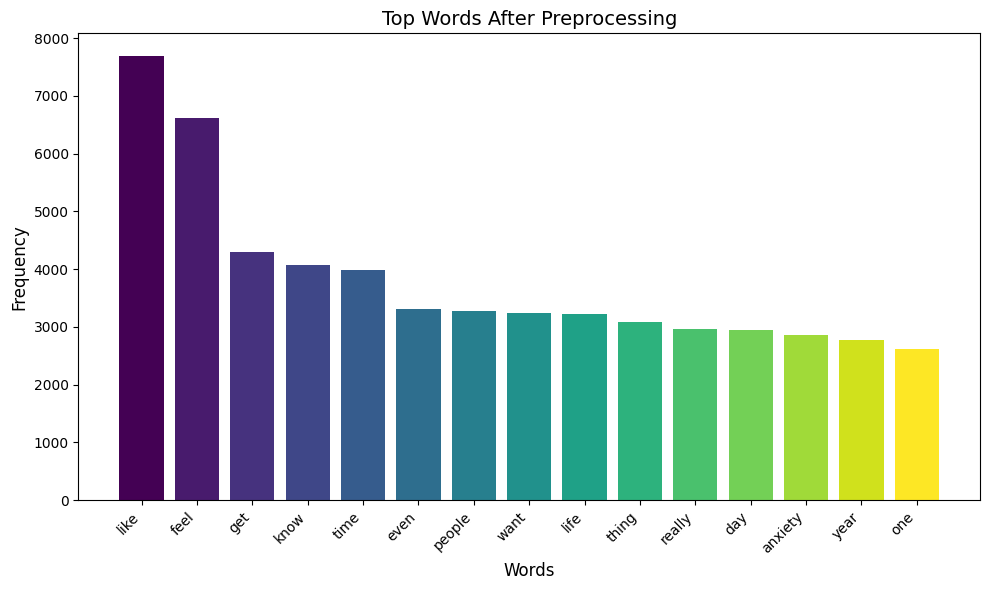

In [4]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
from collections import Counter

# Load dataset
df = pd.read_csv("data_to_be_cleansed.csv")

# Setup NLTK
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Choose best available columns
if 'clean_text' in df.columns and 'clean_title' in df.columns:
    df['combined'] = df['clean_text'] + ' ' + df['clean_title']
elif 'text' in df.columns and 'title' in df.columns:
    df['combined'] = df['text'].astype(str) + ' ' + df['title'].astype(str)
elif 'text' in df.columns:
    df['combined'] = df['text'].astype(str)
else:
    raise ValueError("No text/title columns found for normalization.")

# Preprocessing function
def preprocess_text(text):
    tokens = nltk.word_tokenize(str(text).lower())
    tokens = [w for w in tokens if w.isalpha()]
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

df['processed_text'] = df['combined'].apply(preprocess_text)

# --- Visualization: Top words before vs after ---
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.cm as cm
import numpy as np

def plot_top_words(column, title):
    if column not in df.columns:
        print(f"Column {column} not found, skipping {title}")
        return

    words = " ".join(df[column].dropna()).split()
    if not words:
        print(f"No words found for {title}")
        return

    common = Counter(words).most_common(15)
    labels, counts = zip(*common)


    colors = cm.viridis(np.linspace(0, 1, len(labels)))

    plt.figure(figsize=(10, 6))
    plt.bar(labels, counts, color=colors)
    plt.title(title, fontsize=14)
    plt.xlabel("Words", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Call your functions
plot_top_words("combined", "Top Words Before Preprocessing")
plot_top_words("processed_text", "Top Words After Preprocessing")

